# The Evolution of Automated Fake News Detection

### 1. Traditional ML methods

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Tudor\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tudor\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
true_df = pd.read_csv('dataset/True.csv')
false_df = pd.read_csv('dataset/Fake.csv')

# Add labels to indicate real and fake news
true_df['label'] = 1
false_df['label'] = 0

# Concatenate both datasets
data = pd.concat([true_df, false_df])

print(len(data))
data.sample(5)

44898


,title,text,subject,date,label
17758,Ireland eyes Northern Irish political breakthr...,DUBLIN (Reuters) - Ireland s foreign minister ...,worldnews,"October 11, 2017",1
2821,Senate panel sets hearing for Trump tax nominee,WASHINGTON (Reuters) - The Republican-led Sena...,politicsNews,"July 11, 2017",1
8340,"U.S., India sign military logistics agreement",WASHINGTON (Reuters) - The United States and I...,politicsNews,"August 29, 2016",1
21257,AS JIHADI’S TIES TO ISIS Are Exposed…Obama’s D...,As one would expect the Obama regime is trippi...,left-news,"Dec 4, 2015",0
19503,Armed group seeks legitimacy with Tripoli migr...,"ROME/TUNIS (Reuters) - A powerful armed group,...",worldnews,"September 21, 2017",1


Data Preprocessing <br>

Lowring, tokenizing and remiving stop words.

Tokenization breaks text down into individual words or meaningful units (tokens) by splitting on spaces and punctuation

In [6]:
# Lowercasing and tokenization
data['text'] = data['text'].str.lower()
data['title'] = data['title'].str.lower()
data['text'] = data['text'].apply(nltk.word_tokenize)
data['title'] = data['title'].apply(nltk.word_tokenize)

# Remove stopwords
stop_words = set(stopwords.words('english'))
data['text'] = data['text'].apply(lambda x: [word for word in x if word not in stop_words])
data['title'] = data['title'].apply(lambda x: [word for word in x if word not in stop_words])

Feature Extraction <br>

Term Frequency-Inverse Document Frequency (TF-IDF) is a foundational feature extraction technique in Natural Language Processing (NLP) that converts raw text into meaningful numerical vectors. Unlike simple frequency-based methods like Bag of Words (BoW), TF-IDF highlights words that are unique and relevant to a specific document, while downweighting common, less informative words (like "the", "a", "is") across a corpus.

In [7]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
text_tfidf = tfidf_vectorizer.fit_transform(data['text'].apply(lambda x: ' '.join(x)))
title_tfidf = tfidf_vectorizer.transform(data['title'].apply(lambda x: ' '.join(x)))

Split the Data into Training and Testing Sets

In [8]:
X = text_tfidf
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Display the shapes of training and testing data
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (35918, 5000)
X_test shape: (8980, 5000)
y_train shape: (35918,)
y_test shape: (8980,)


# Model Training
1. Multinomial Naive Bayes Model

In [45]:
naive_bayes_model = MultinomialNB()
naive_bayes_model.fit(X_train, y_train)

y_pred = naive_bayes_model.predict(X_test)

nvb_accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {nvb_accuracy:.2f}")


print(y_train[1])

prediction = naive_bayes_model.predict(X_train[3])
print(prediction)

Accuracy: 0.94
0
[0]


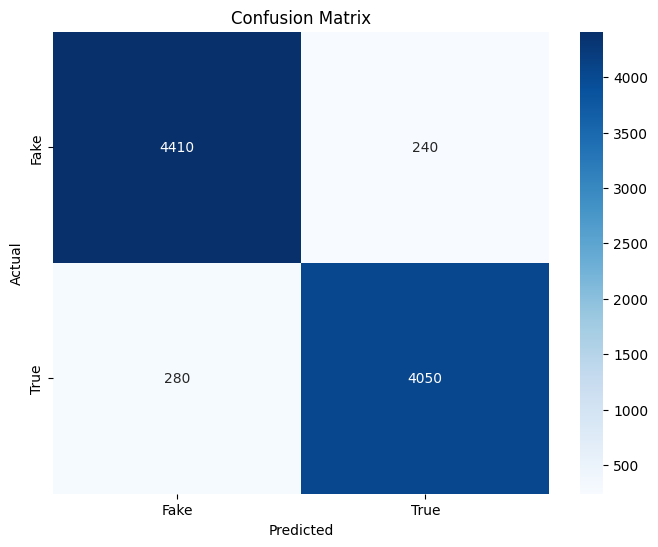

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      4650
           1       0.94      0.94      0.94      4330

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



In [34]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'True'], yticklabels=['Fake', 'True'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print the classification report
print("Classification Report:")
print(classification_rep)

2. Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

# Define and train the Random Forest model
random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(X_train, y_train)

# Evaluate the Random Forest model
def evaluate_random_forest(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    confusion = confusion_matrix(y_test, y_pred)
    classification_rep = classification_report(y_test, y_pred)

    return accuracy, confusion, classification_rep

# Evaluate Random Forest
rf_accuracy, rf_confusion, rf_classification = evaluate_random_forest(random_forest, X_test, y_test)
print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Confusion Matrix:\n", rf_confusion)
print("Random Forest Classification Report:\n", rf_classification)

Random Forest Accuracy: 0.9983296213808464
Random Forest Confusion Matrix:
 [[4643    7]
 [   8 4322]]
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4650
           1       1.00      1.00      1.00      4330

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



3. Logistic Regression

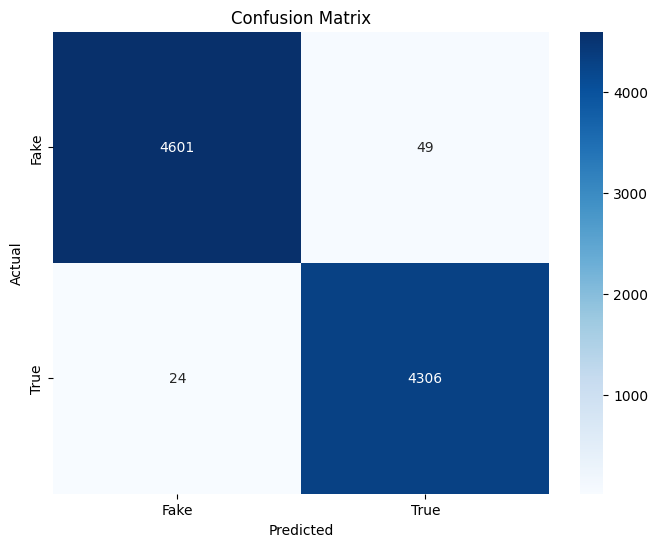

Logistic Regression Accuracy: 0.9918708240534521
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4650
           1       0.99      0.99      0.99      4330

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [39]:
from sklearn.linear_model import LogisticRegression

# Define and train the Logistic Regression model
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train, y_train)

# Evaluate the Logistic Regression model
def evaluate_logistic_regression(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    confusion = confusion_matrix(y_test, y_pred)
    classification_rep = classification_report(y_test, y_pred)

    return accuracy, confusion, classification_rep

# Evaluate Logistic Regression
lr_accuracy, lr_confusion, lr_classification = evaluate_logistic_regression(logistic_regression, X_test, y_test)
plt.figure(figsize=(8, 6))
sns.heatmap(lr_confusion, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'True'], yticklabels=['Fake', 'True'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Logistic Regression Accuracy:", lr_accuracy)
print("Logistic Regression Classification Report:\n", lr_classification)

### Model Validation and Evaluation

Random forest

In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Testing the Random Forest model on the test data
rf_test_predictions = random_forest.predict(X_test)

# Evaluate Random Forest on the test data
rf_test_precision = precision_score(y_test, rf_test_predictions)
rf_test_recall = recall_score(y_test, rf_test_predictions)
rf_test_f1 = f1_score(y_test, rf_test_predictions)

# Print precision, recall, and F1 score for Random Forest
print("Random Forest Test Precision:", rf_test_precision)
print("Random Forest Test Recall:", rf_test_recall)
print("Random Forest Test F1 Score:", rf_test_f1)

Random Forest Test Precision: 0.9983829983829984
Random Forest Test Recall: 0.9981524249422633
Random Forest Test F1 Score: 0.9982676983485391


Logistic Regression

In [43]:

from sklearn.metrics import precision_score, recall_score, f1_score

# Testing and evaluating Logistic Regression
lr_test_predictions = logistic_regression.predict(X_test)
lr_test_precision = precision_score(y_test, lr_test_predictions)
lr_test_recall = recall_score(y_test, lr_test_predictions)
lr_test_f1 = f1_score(y_test, lr_test_predictions)

# Print precision, recall, and F1 score for Logistic Regression
print("Logistic Regression Test Precision:", lr_test_precision)
print("Logistic Regression Test Recall:", lr_test_recall)
print("Logistic Regression Test F1 Score:", lr_test_f1)

Logistic Regression Test Precision: 0.9887485648679678
Logistic Regression Test Recall: 0.9944572748267898
Logistic Regression Test F1 Score: 0.991594703511802


MultinomialNB

In [44]:
nvb_test_predictions = naive_bayes_model.predict(X_test)
nvb_test_precision = precision_score(y_test, nvb_test_predictions)
nvb_test_recall = recall_score(y_test, nvb_test_predictions)
nvb_test_f1 = f1_score(y_test, nvb_test_predictions)

print("Logistic Regression Test Precision:", nvb_test_precision)
print("Logistic Regression Test Recall:", nvb_test_recall)
print("Logistic Regression Test F1 Score:", nvb_test_f1)

Logistic Regression Test Precision: 0.9440559440559441
Logistic Regression Test Recall: 0.9353348729792148
Logistic Regression Test F1 Score: 0.9396751740139211


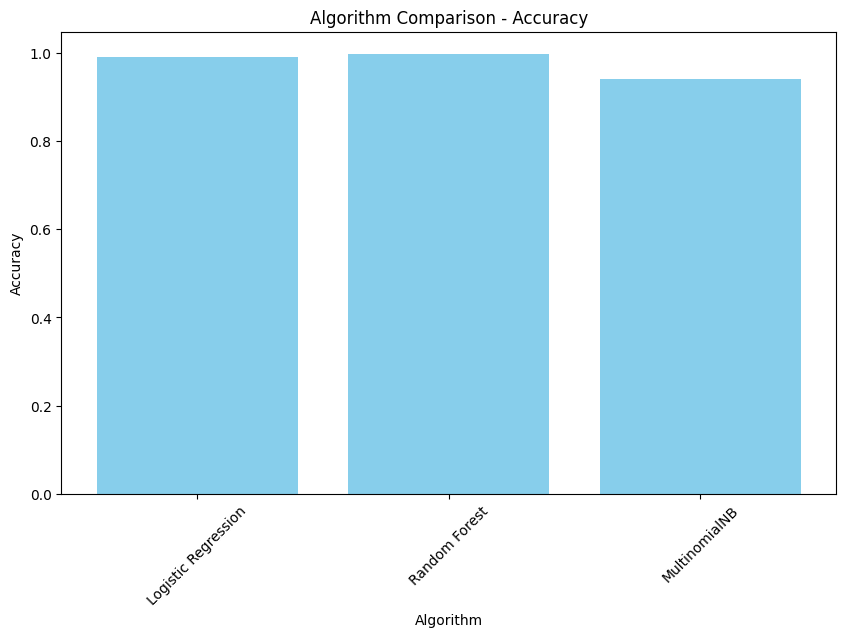

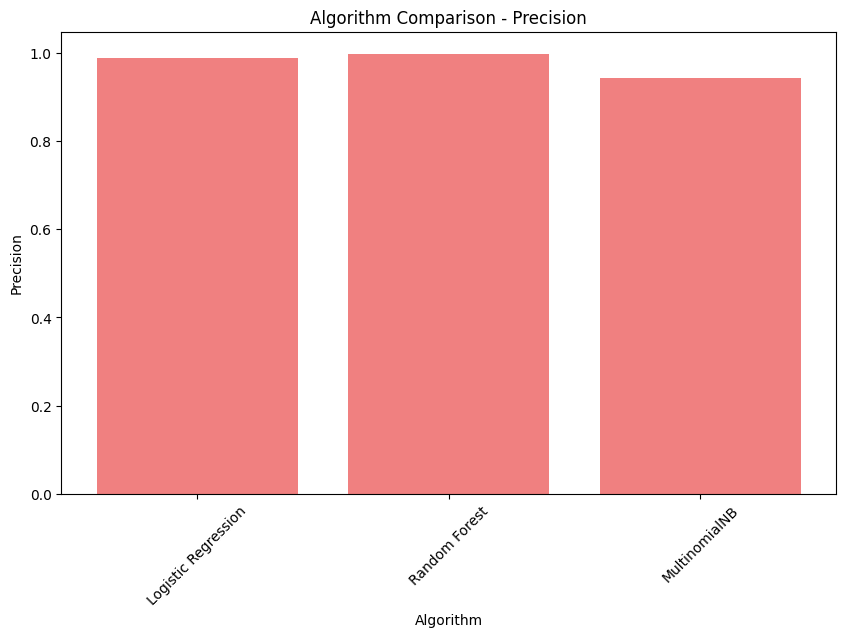

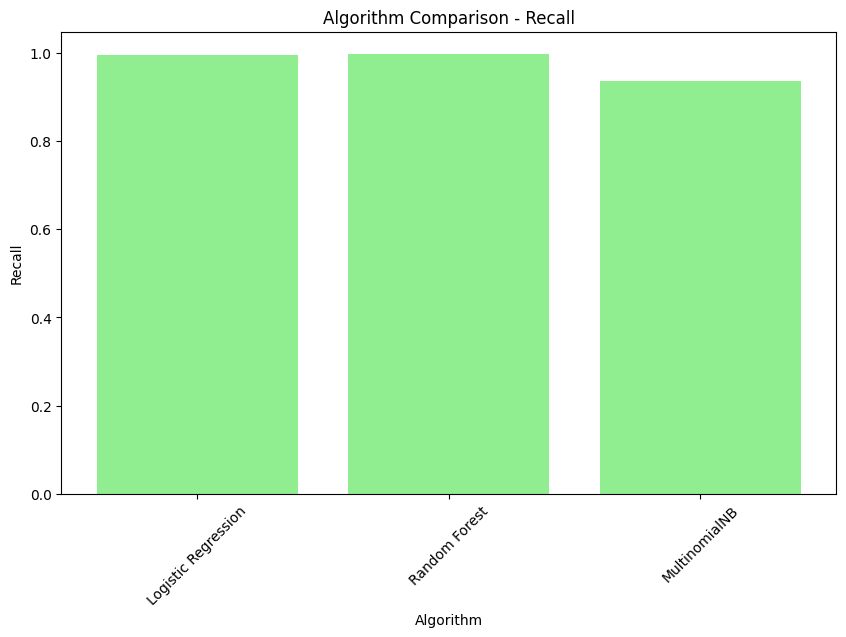

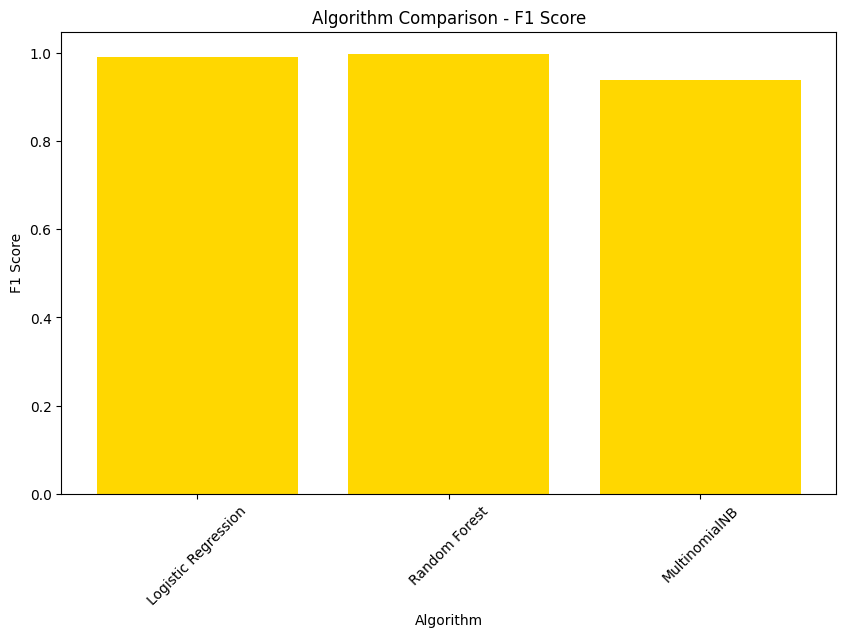

In [47]:
import matplotlib.pyplot as plt

# Define the algorithm names and their corresponding metrics
algorithms = ['Logistic Regression', 'Random Forest', 'MultinomialNB']
accuracies = [lr_accuracy, rf_accuracy, nvb_accuracy]
precisions = [lr_test_precision, rf_test_precision, nvb_test_precision]
recalls = [lr_test_recall, rf_test_recall, nvb_test_recall]
f1_scores = [lr_test_f1, rf_test_f1, nvb_test_f1]

# Create a bar chart for accuracy
plt.figure(figsize=(10, 6))
plt.bar(algorithms, accuracies, color='skyblue')
plt.xlabel('Algorithm')
plt.ylabel('Accuracy')
plt.title('Algorithm Comparison - Accuracy')
plt.xticks(rotation=45)
plt.show()

# Create a bar chart for precision
plt.figure(figsize=(10, 6))
plt.bar(algorithms, precisions, color='lightcoral')
plt.xlabel('Algorithm')
plt.ylabel('Precision')
plt.title('Algorithm Comparison - Precision')
plt.xticks(rotation=45)
plt.show()

# Create a bar chart for recall
plt.figure(figsize=(10, 6))
plt.bar(algorithms, recalls, color='lightgreen')
plt.xlabel('Algorithm')
plt.ylabel('Recall')
plt.title('Algorithm Comparison - Recall')
plt.xticks(rotation=45)
plt.show()

# Create a bar chart for F1 score
plt.figure(figsize=(10, 6))
plt.bar(algorithms, f1_scores, color='gold')
plt.xlabel('Algorithm')
plt.ylabel('F1 Score')
plt.title('Algorithm Comparison - F1 Score')
plt.xticks(rotation=45)
plt.show()

<Figure size 1200x1000 with 0 Axes>

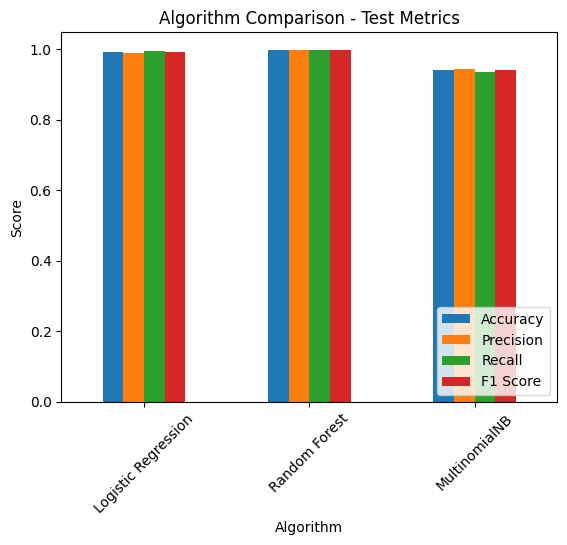

In [51]:
results_df = pd.DataFrame({
    'Algorithm': algorithms,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1 Score': f1_scores
})

results_df.set_index('Algorithm', inplace=True)

plt.figure(figsize=(12, 10))
results_df.plot(kind='bar', stacked=False)
plt.xlabel('Algorithm')
plt.ylabel('Score')
plt.title('Algorithm Comparison - Test Metrics')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.show()